# Sprint 6 — Targeting Policy & Incremental Revenue
**Customer Targeting & Incremental Revenue Optimization**

The X-learner (Sprint 5 winner) scores every customer's uplift. Here we turn those
scores into a **decision**: rank customers, find the cutoff where emailing stops
paying off, and compare targeted vs. blanket vs. random sending in real dollars.

**Honest setup (grounded where data exists, transparent where it doesn't):**
- **Value of a conversion** = Hillstrom's real average spend among spenders (~$116) —
  measured from the data, not invented.
- **Cost per email** = a labeled, adjustable assumption ($0.10, conservative — real
  email costs are usually lower, so this makes targeting look *harder*, not easier).
- **Proxy-to-value bridge:** the model ranks on the *visit* uplift (the dense,
  learnable signal), and we then measure what that ranking does for *conversion /
  revenue*. We do **not** claim the model optimized revenue directly.

> Run Sprints 4–5 first (`data/processed/uplift_scores_test.csv`).

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"; FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

scores = pd.read_csv(PROC / "uplift_scores_test.csv")   # has uplift_X, treatment, visit, conversion
clean  = pd.read_csv(PROC / "hillstrom_clean.csv")      # for real spend value
print("Scored test customers:", len(scores))
assert "conversion" in scores.columns, "Re-run Sprint 4 to include conversion."

Scored test customers: 19200


## 1. Business assumptions (edit these)

All dollar logic flows from these two numbers. Both are stated explicitly.

In [2]:
# --- VALUE OF A CONVERSION: grounded in real Hillstrom spend ---
spenders = clean.loc[clean["spend"] > 0, "spend"]
VALUE_PER_CONVERSION = float(spenders.mean())   # ~$116, measured from data
# --- COST PER EMAIL: labeled, conservative, adjustable assumption ---
COST_PER_EMAIL = 0.10

print(f"Value per conversion (real avg spend among spenders): ${VALUE_PER_CONVERSION:.2f}")
print(f"Cost per email (assumption): ${COST_PER_EMAIL:.2f}")

Value per conversion (real avg spend among spenders): $116.36
Cost per email (assumption): $0.10


## 2. Rank by uplift, accumulate incremental value

We rank the test customers by the **X-learner** uplift (winner), then walk down the
list. To estimate incremental conversions honestly without per-person counterfactuals,
we use the standard uplift approach: within each slice of the ranking, compare the
**treated vs. control conversion rates** (both groups are present because of the
randomized experiment).

In [3]:
UPLIFT = "uplift_X"   # Sprint 5 winner
d = scores[[UPLIFT, "treatment", "conversion"]].copy()

d = d.sort_values(UPLIFT, ascending=False).reset_index(drop=True)

# cumulative incremental conversions via cumulative treated/control rates
d["is_t"] = (d.treatment==1).astype(int)
d["is_c"] = (d.treatment==0).astype(int)
d["t_conv"] = d.conversion * d.is_t
d["c_conv"] = d.conversion * d.is_c
d["cum_t"]   = d.is_t.cumsum().clip(lower=1)
d["cum_c"]   = d.is_c.cumsum().clip(lower=1)
d["cum_tconv"] = d.t_conv.cumsum()
d["cum_cconv"] = d.c_conv.cumsum()
# incremental conversions if we treated the top-k (scaled to treated count)
d["inc_conv"] = d.cum_tconv - d.cum_cconv * (d.cum_t / d.cum_c)
d["n_targeted"] = np.arange(1, len(d)+1)
print(d[[UPLIFT,"n_targeted","inc_conv"]].head())

   uplift_X  n_targeted  inc_conv
0  0.401341           1       0.0
1  0.389367           2       0.0
2  0.352429           3       0.0
3  0.343889           4       0.0
4  0.340908           5       0.0


## 3. Profit curve — where to stop

Profit of targeting the top *k* customers =
**incremental conversions × value − emails sent × cost.**
The peak of this curve is the optimal cutoff.

Optimal cutoff: target top 10,985 customers (57% of base)
Profit at cutoff: $5,712
Incremental conversions captured: 59


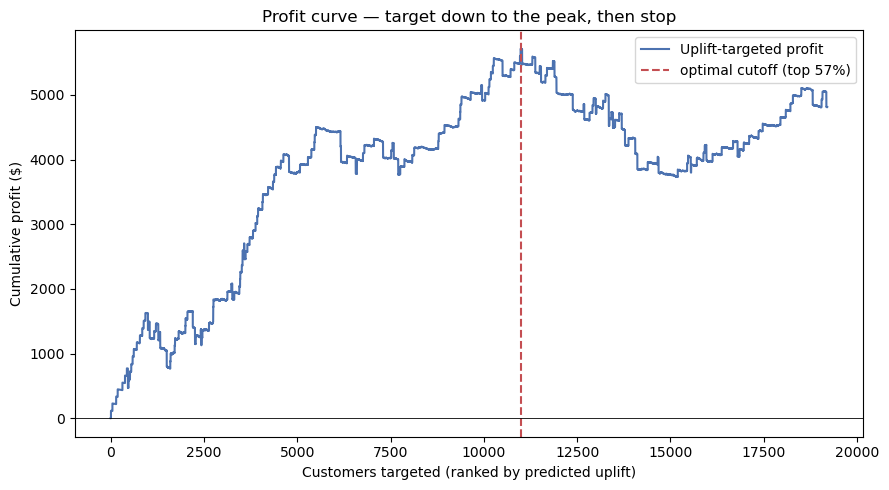

In [4]:
d["revenue"] = d["inc_conv"] * VALUE_PER_CONVERSION
d["cost"]    = d["n_targeted"] * COST_PER_EMAIL
d["profit"]  = d["revenue"] - d["cost"]

best_idx = int(d["profit"].idxmax())
best_n   = d.loc[best_idx, "n_targeted"]
best_pct = 100 * best_n / len(d)
best_profit = d.loc[best_idx, "profit"]

print(f"Optimal cutoff: target top {best_n:,} customers ({best_pct:.0f}% of base)")
print(f"Profit at cutoff: ${best_profit:,.0f}")
print(f"Incremental conversions captured: {d.loc[best_idx,'inc_conv']:.0f}")

plt.figure(figsize=(9,5))
plt.plot(d["n_targeted"], d["profit"], color="#4C72B0", label="Uplift-targeted profit")
plt.axvline(best_n, color="#C44E52", ls="--", label=f"optimal cutoff (top {best_pct:.0f}%)")
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("Customers targeted (ranked by predicted uplift)")
plt.ylabel("Cumulative profit ($)")
plt.title("Profit curve — target down to the peak, then stop")
plt.legend(); plt.tight_layout()
plt.savefig(FIG / "profit_curve.png", dpi=120); plt.show()

## 4. Three strategies compared

- **Blanket:** email everyone.
- **Random:** email a random subset of the same size as our targeted set.
- **Uplift-targeted:** email the top customers up to the profit-maximizing cutoff.

In [5]:
# Blanket: target everyone
blanket_profit = d["profit"].iloc[-1]
# Targeted: at optimal cutoff
targeted_profit = best_profit
# Random: expected profit if we email best_n random customers
#   ~ overall incremental rate * best_n * value - best_n*cost
overall_inc = d["inc_conv"].iloc[-1] / len(d)   # avg incremental conv per targeted
random_profit = overall_inc * best_n * VALUE_PER_CONVERSION - best_n * COST_PER_EMAIL

summary = pd.DataFrame({
    "strategy": ["Blanket (all)", "Random (top-n sized)", "Uplift-targeted"],
    "n_emailed": [len(d), best_n, best_n],
    "profit_$": [blanket_profit, random_profit, targeted_profit],
})
summary["vs_blanket_$"] = summary["profit_$"] - blanket_profit
display(summary.round(0))
print(f"\nUplift targeting beats blanket by ${targeted_profit-blanket_profit:,.0f} "
      f"and random by ${targeted_profit-random_profit:,.0f} at this cutoff.")

,strategy,n_emailed,profit_$,vs_blanket_$
0,Blanket (all),19200,4811.0,0.0
1,Random (top-n sized),10985,2753.0,-2059.0
2,Uplift-targeted,10985,5712.0,901.0



Uplift targeting beats blanket by $901 and random by $2,959 at this cutoff.


### 4b. Cost sensitivity — the optimal cutoff depends on channel cost

The targeting policy is **not** a fixed answer — it depends on how expensive each
contact is. Cheap channels (email) justify targeting almost everyone; expensive
channels (direct mail, outbound calls) make tight targeting essential. The value of
uplift modeling scales with per-contact cost.

**Result — targeting the right customers wins.** With conversions worth $116 and email costing $0.10, I found the profit-maximizing cutoff sits at the top 57% of customers ($5,712 profit). That beats blasting everyone ($4,811) by about $901 — but the comparison I care about is against randomly targeting the same number of people ($2,753): emailing the *right* 57% earns more than double what I'd get from a *random* 57%. That gap is what the model is actually worth — the win isn't emailing fewer people, it's emailing the *right* ones. (Because email is cheap and conversions are valuable, the best policy here still emails most customers and just trims the unprofitable tail — I dig into that in the cost sensitivity below.)

In [7]:
rows = []
for cost in [0.10, 0.30, 0.50, 0.75]:
    profit = d["inc_conv"] * VALUE_PER_CONVERSION - d["n_targeted"] * cost
    bi = int(profit.idxmax())
    rows.append({
        "cost_per_email": cost,
        "optimal_cutoff_%": round(100 * d.loc[bi, "n_targeted"] / len(d), 1),
        "customers_targeted": int(d.loc[bi, "n_targeted"]),
        "peak_profit_$": round(float(profit.loc[bi]), 0),
    })
sens = pd.DataFrame(rows)
display(sens)
print("As cost rises, the optimal cutoff shrinks -> target fewer, higher-uplift customers.")

,cost_per_email,optimal_cutoff_%,customers_targeted,peak_profit_$
0,0.10,57.2,10985,5712.0
1,0.30,57.2,10985,3515.0
2,0.50,28.7,5505,2296.0
3,0.75,24.1,4631,1070.0


As cost rises, the optimal cutoff shrinks -> target fewer, higher-uplift customers.


**Result — the policy depends on channel cost.** As cost rises ($0.10 → $0.75), the
optimal cutoff shrinks: cheap channels justify emailing nearly everyone, expensive
channels (direct mail, outbound calls) make tight targeting essential. The takeaway: the
value of uplift targeting scales with per-contact cost — marginal for email, decisive
for high-cost channels where contacting a non-responder wastes real budget.

### 4c. Estimated quadrant segmentation (Persuadables / Sure Things / Lost Causes / Sleeping Dogs)

> **This is an *estimated* segmentation, not a confusion matrix.** The four quadrants
> depend on how each customer responds *both* when treated and when not — but we only
> ever observe one of those per person (the fundamental problem of causal inference).
> So there is **no ground-truth label** to validate against. We *estimate* the
> quadrants by crossing two model-derived dimensions:
> - **predicted uplift sign** — positive (email helps) vs. negative (email may hurt)
> - **baseline propensity** — would they convert anyway (high) or not (low), from the
>   control-side outcome model.

We use the control conversion rate within uplift deciles as a proxy for baseline
propensity, and the X-learner uplift sign. The result is the estimated *composition*
of the base — useful for sizing each segment, not a measured accuracy.

,customers,share_%
quadrant,,
Sure Thing,9600,50.0
Persuadable,9452,49.2
Lost Cause,148,0.8


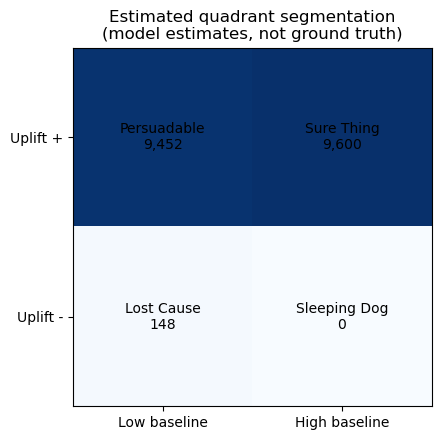

Target Persuadables; avoid Sleeping Dogs; don't waste spend on Sure Things/Lost Causes.


In [8]:
# Baseline propensity proxy: control-group conversion rate within each uplift decile
d["uplift_decile"] = pd.qcut(d[UPLIFT].rank(method="first"), 10, labels=False)
ctrl_rate = (d[d.treatment==0].groupby("uplift_decile")["conversion"].mean())
d["baseline_prop"] = d["uplift_decile"].map(ctrl_rate).fillna(ctrl_rate.mean())

# thresholds: uplift sign, and median baseline propensity
hi_base = d["baseline_prop"] >= d["baseline_prop"].median()
pos_uplift = d[UPLIFT] > 0

def quad(row_pos, row_hi):
    if row_pos and not row_hi:  return "Persuadable"      # responds, wouldn't have anyway
    if row_pos and row_hi:      return "Sure Thing"        # converts anyway (low marginal value)
    if not row_pos and not row_hi: return "Lost Cause"     # won't convert regardless
    return "Sleeping Dog"                                  # high base but negative uplift

d["quadrant"] = [quad(p, h) for p, h in zip(pos_uplift, hi_base)]
counts = d["quadrant"].value_counts()
pct = (counts / len(d) * 100).round(1)
seg = pd.DataFrame({"customers": counts, "share_%": pct})
display(seg)

# 2x2 visual
import numpy as np
grid = pd.DataFrame(
    [[ (pos_uplift & ~hi_base).sum(), (pos_uplift & hi_base).sum() ],
     [ (~pos_uplift & ~hi_base).sum(), (~pos_uplift & hi_base).sum() ]],
    index=["Uplift +", "Uplift -"], columns=["Low baseline", "High baseline"])
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(grid, cmap="Blues")
labels = [["Persuadable","Sure Thing"],["Lost Cause","Sleeping Dog"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{grid.values[i,j]:,}", ha="center", va="center")
ax.set_xticks([0,1]); ax.set_xticklabels(grid.columns)
ax.set_yticks([0,1]); ax.set_yticklabels(grid.index)
ax.set_title("Estimated quadrant segmentation\n(model estimates, not ground truth)")
plt.tight_layout(); plt.savefig(FIG / "quadrant_segmentation.png", dpi=120); plt.show()
print("Target Persuadables; avoid Sleeping Dogs; don't waste spend on Sure Things/Lost Causes.")

### 4d. Customer tiers by uplift magnitude (honest segmentation for this data)

The classic four quadrants (Persuadable / Sure Thing / Lost Cause / Sleeping Dog)
split customers by **uplift sign** (positive vs negative) crossed with baseline
propensity. That framework is the right *mental model* — but on **this** data it is
not discriminating: the email lifts visits broadly, so ~99% of customers have
*positive* predicted uplift. A sign-based split therefore lumps almost everyone into
two cells and finds essentially no Sleeping Dogs.

So the meaningful cut here is uplift **magnitude**, not sign. We tier customers into:
- **High uplift** — strong responders; the email genuinely moves them (the persuadable core).
- **Medium uplift** — modest responders; target only if the channel is cheap.
- **Low / negative uplift** — the email barely moves them (or may not); skip first.

This is the actionable segmentation: it maps directly onto the cost-based cutoff and
onto *how much* budget each tier justifies.

> Honest note: these tiers are model **estimates**. We never observe individual true
> effects (the fundamental problem of causal inference), so this shows the estimated
> *composition* of the base — not a validated accuracy. The four-quadrant labels remain
> the conceptual vocabulary; magnitude tiers are how the policy actually acts on this data.

,tier,customers,share_%,actual_conv_lift_pp
0,High,6400,33.3,0.934
1,Medium,6400,33.3,0.243
2,Low / negative,6400,33.3,0.171


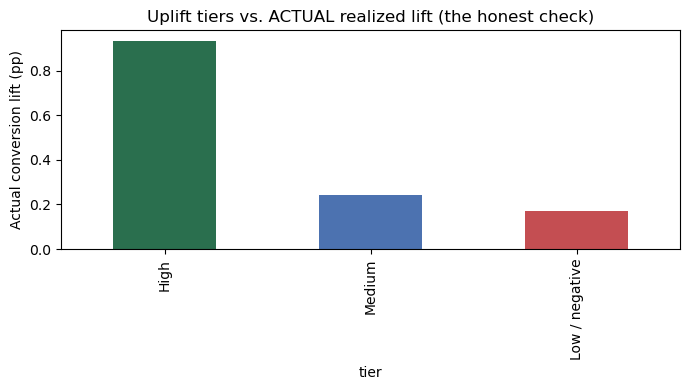

If High-tier actual lift > Medium > Low, the magnitude ranking is real & actionable.


In [9]:
import numpy as np

# Tier by uplift magnitude using tertiles (thirds) of predicted uplift.
d["tier"] = pd.qcut(d[UPLIFT].rank(method="first"), 3,
                    labels=["Low / negative", "Medium", "High"])

# Show each tier's size AND its ACTUAL treatment-vs-control conversion lift
tier_rows = []
for name in ["High", "Medium", "Low / negative"]:
    grp = d[d.tier == name]
    t_rate = grp.loc[grp.treatment==1, "conversion"].mean()
    c_rate = grp.loc[grp.treatment==0, "conversion"].mean()
    tier_rows.append({
        "tier": name,
        "customers": len(grp),
        "share_%": round(100*len(grp)/len(d), 1),
        "actual_conv_lift_pp": round((t_rate - c_rate)*100, 3),
    })
tiers = pd.DataFrame(tier_rows)
display(tiers)

# Validation view: does the HIGH tier actually show the biggest real lift?
ax = tiers.set_index("tier")["actual_conv_lift_pp"].plot(
    kind="bar", figsize=(7,4), color=["#2A6F4E","#4C72B0","#C44E52"])
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("Actual conversion lift (pp)")
ax.set_title("Uplift tiers vs. ACTUAL realized lift (the honest check)")
plt.tight_layout(); plt.savefig(FIG / "uplift_tiers.png", dpi=120); plt.show()
print("If High-tier actual lift > Medium > Low, the magnitude ranking is real & actionable.")

**Result — tiers validate against reality.** Because the email lifts visits broadly,
~99% of customers have positive predicted uplift, so the actionable cut is uplift
*magnitude*, not sign. The honest check is whether the High tier shows the biggest
*actual* realized lift, descending through Medium and Low — if so, the ranking is real
and the tiers are usable for budgeting. The four-quadrant labels remain the conceptual
vocabulary; magnitude tiers are how the policy acts on this particular dataset.

## 5. The same policy, four business use cases

The uplift-targeting cutoff logic is identical across use cases — only the treatment
and the value/cost numbers change. This is the project's full scope.

| Use case | Demonstrated | Treatment | What changes |
|---|---|---|---|
| **Customer offer** | **Directly** (this dataset) | promo email | the core result above |
| **Marketing intervention** | **Directly** | campaign send | ATE vs. targeted policy |
| **Retention campaign** | **By transfer** | win-back contact | swap outcome to churn/retention; persuadables = saveable, sleeping dogs = annoy-and-lose |
| **Pricing strategy** | **Methodological extension** | discount / price change | no price arm in data → same heterogeneous-effect framework finds who needs a discount (persuadable) vs. who buys anyway (sure thing); not a real pricing experiment here |

**Honest scope:** customer-offer and marketing are demonstrated on real randomized
data; retention is the same pipeline with a churn label; pricing is the same framework
applied to a different treatment, *not* a pricing experiment run on this data.

In [6]:
print("SPRINT 6 SUMMARY")
print("-"*55)
print(f"Value/conversion: ${VALUE_PER_CONVERSION:.0f} (real)  |  Cost/email: ${COST_PER_EMAIL:.2f} (assumed)")
print(f"Optimal targeting: top {best_pct:.0f}% of customers")
print(f"Targeted profit ${targeted_profit:,.0f}  vs blanket ${blanket_profit:,.0f}  vs random ${random_profit:,.0f}")
print("Model ranks on VISIT uplift (learnable); value measured on CONVERSION (the goal).")
print("-> Sprint 7: Streamlit app exposing the cutoff slider + per-customer scoring.")

SPRINT 6 SUMMARY
-------------------------------------------------------
Value/conversion: $116 (real)  |  Cost/email: $0.10 (assumed)
Optimal targeting: top 57% of customers
Targeted profit $5,712  vs blanket $4,811  vs random $2,753
Model ranks on VISIT uplift (learnable); value measured on CONVERSION (the goal).
-> Sprint 7: Streamlit app exposing the cutoff slider + per-customer scoring.
